In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
X = [50, 60, 70, 80, 90]     # مساحه البيت بالمتر المربع 
Y = [150, 180, 210, 240, 270]  # سعر البيت بالالف 

In [7]:
x = np.array(X)
y = np.array(Y)

In [38]:
class LinearRegressionGD:
    '''Linear Regression implemented using Gradient Descent'''
    def __init__(self, learning_rate = 0.001 , n_iters = 100):
        '''Initialize the Linear Regression model
        Parameters:
            learning_rate : Step size used in Gradient Descent.
            n_iters : Number of iterations for training
        
        '''
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_value = []

    def fit(self, x, y):
        '''Train the Linear Regression model using Gradient Descent'''
        n = len(x)
        for _ in range(self.n_iters):
            y_hat = self.theta_1 * x + self.theta_0
            d_theta_1 = (2/n) * np.sum((y_hat - y) * x)
            d_theta_0 = (2/n) * np.sum(y_hat - y)    

            self.theta_1 -= self.learning_rate * d_theta_1
            self.theta_0 -= self.learning_rate * d_theta_0
            y_hat = self.theta_1 * x + self.theta_0
            sse = np.sum((y_hat - y) **2)
            self.sse_value.append(sse)
    def predict(self, x):
        '''Predict the target values for given input features'''
        x = np.array(x)

        return self.theta_1 * x + self.theta_0
    

    def calculate_mse(self, x, y):
        '''Calculate Mean Squared Error'''
        y_hat = self.predict(x)
        mse = np.mean((y_hat - y) ** 2)
        return mse


    def plot_training(self ,x ,y):
        '''plot the training data and the fitted line'''
        plt.figure(figsize=(12, 5)) 
        plt.subplot(1, 2, 1)
        plt.plot(range(self.n_iters) , self.sse_value , label = 'SSE')
        plt.xlabel('Iterations')
        plt.ylabel('SSE')
        plt.title('SSE vs Iteration')

        plt.subplot(1,2,2)
        plt.scatter(x, y, color = 'b' , label = 'Actual Data')
        plt.plot(x, self.predict(x) , color = 'r' , label = 'Regression Line')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Linear Regression Fit')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [39]:
model = LinearRegressionGD(learning_rate = 0.0001 , n_iters = 100)
model.fit(x,y)


In [40]:
print(f"theta_0: {model.theta_0}, theta_1: {model.theta_1}")


theta_0: 0.04113676040970018, theta_1: 2.999435373457505


In [41]:
Predictions = model.predict(x)
print(f"Predictions  :{Predictions}")

Predictions  :[150.01290543 180.00725917 210.0016129  239.99596664 269.99032037]


In [42]:
mse_value = model.calculate_mse(x, y)
print("MSE:", mse_value)

MSE: 6.636208076299688e-05


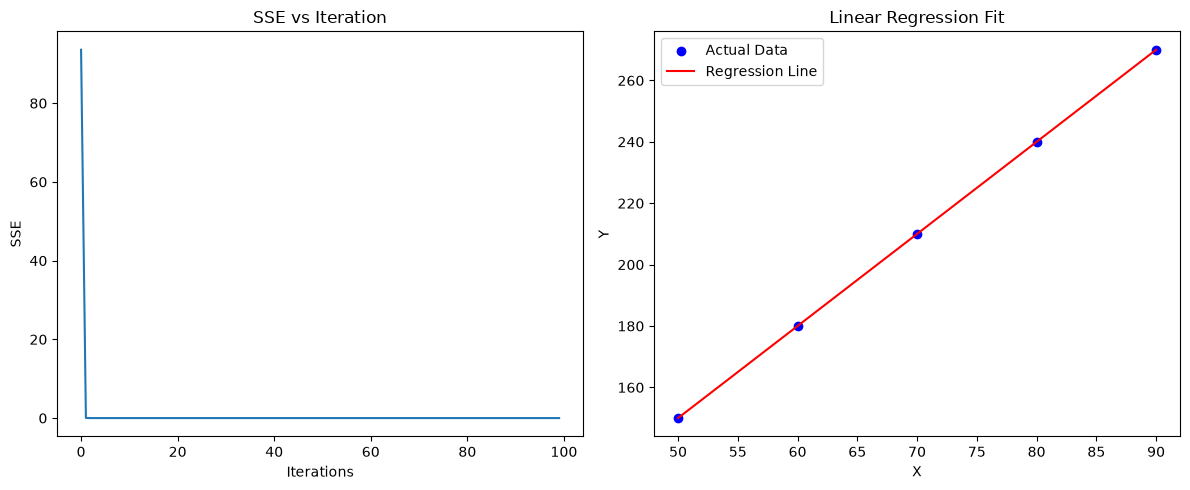

In [21]:
model.plot_training(x, y)

In [50]:
model_large = LinearRegressionGD(learning_rate = 0.001 , n_iters = 100)
model_large.fit(x, y)
print(f"theta_0: {model_large.theta_0}, theta_1: {model_large.theta_1}")

theta_0: -1.0055957901462392e+95, theta_1: -7.326427288635144e+96


In [31]:
Predictions = model_small.predict(x)
print(f"Predictions  :{Predictions}")

Predictions  :[-3.66421924e+98 -4.39686197e+98 -5.12950470e+98 -5.86214743e+98
 -6.59479016e+98]


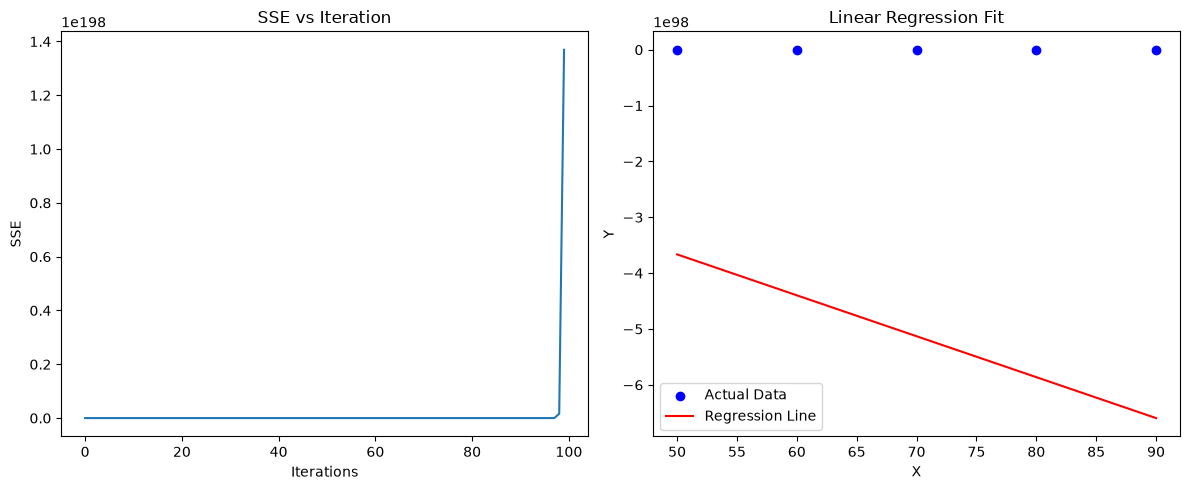

In [32]:
model.plot_training(x, y)

## What do theta_0 and theta_1 represent in the regression equation?

theta_0 = intercept (b)

theta_1 = slope (w)

## 1. Use the trained model to predict the price of a house with size: o 70 m² 
## 2. Print the predicted value. 

In [ ]:
prediction_70 = model.predict([70])

print(f"Predicted price for 70 m²: {prediction_70}")

Predicted price for 70 m²: [210.0016129]


## Is the prediction reasonable based on the dataset? Why? 

yes, in the real data the house which area = 70 m2 = 210 k

## Why SSE decreases over time

SSE بتقل مع الوقت علشان Gradient Descent بتغير قيم theta_0 و theta_1 كل مره علشان التوقعات تقترب من القيم الحقيقيه اكتر وطبيعي كل ما الفرق بين التوقع والقيمه الحقيقه يصغر ال SSE هيقل هوا كمان 

## What convergence means in Gradient Descent

convergence معناها ان ال Gradient Descent وصل لمرحله ان قيم theta_0 و theta_1 بقت مستقره ومش بتتغير كتير 

## What happens if the learning rate is too large?

The model may overshoot the minimum instead of moving toward it. The SSE can increase instead of decrease, and Gradient Descent may fail to converge.

## Bonus Tasks 

Normalize X before training and compare results

In [68]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(x, y)

In [69]:
X_norm = (x - np.mean(x)) / np.std(x)

In [70]:
model_norm = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model_norm.fit(X_norm, y)

In [71]:
print("Original final SSE:", model.sse_value[-1])
print("Normalizedfinal SSE:", model_norm.sse_value[-1])

Original final SSE: 1.3692674590710947e+198
Normalizedfinal SSE: 153776.84535283034


In [72]:
print("Original theta_0:", model.theta_0, " theta_1:", model.theta_1)
print("Normalized theta_0:", model_norm.theta_0, " theta_1:", model_norm.theta_1)

Original theta_0: -1.0055957901462392e+95  theta_1: -7.326427288635144e+96
Normalized theta_0: 38.100971015430154  theta_1: 7.697558564229364
